In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# **Getting Data Insights**

In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [ ]:
df.shape

(7043, 21)

In [ ]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
cols = ['MultipleLines','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']

In [ ]:
df[cols] = df[cols].replace({'No phone service':'No',
                             'No internet service' : 'No'})

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
df['Churn'].value_counts()/df.shape[0] * 100

,count
Churn,
No,73.463013
Yes,26.536987


In [ ]:
df['PaymentMethod'] = df['PaymentMethod'].replace({'Bank transfer (automatic)':'Bank transfer',
                                                   'Credit card (automatic)':'Credit card'})

In [ ]:
df = df.drop('customerID',axis=1)

In [ ]:
df['SeniorCitizen'] = df['SeniorCitizen'].replace({0:'NO',
                                                   1:'Yes'}).astype('object')


# **Data Analysis using visualization**


<Axes: xlabel='PaymentMethod', ylabel='count'>

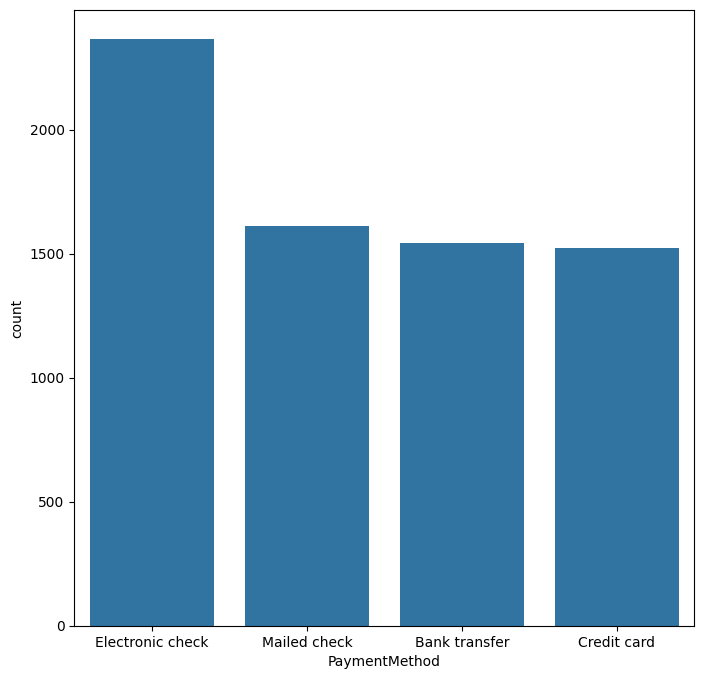

In [ ]:
plt.figure(figsize=[8,8])
sns.countplot(x='PaymentMethod',data=df)

<Axes: xlabel='MonthlyCharges', ylabel='Count'>

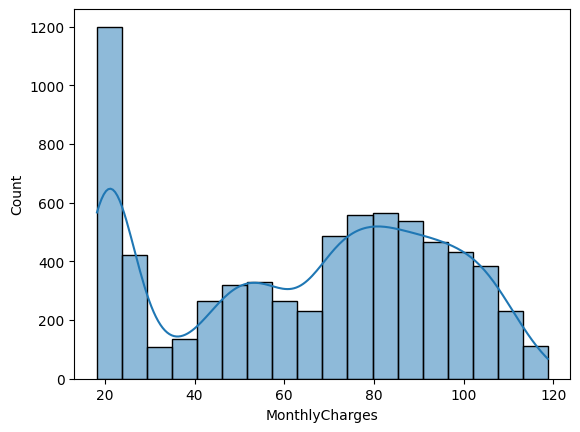

In [ ]:
sns.histplot(x='MonthlyCharges',data=df,kde=True)

<Axes: xlabel='MonthlyCharges', ylabel='InternetService'>

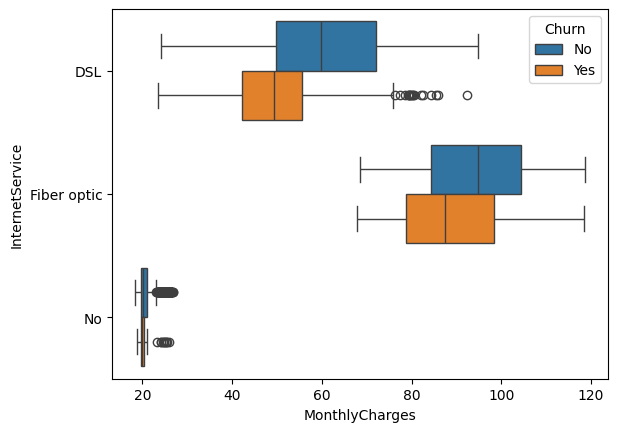

In [ ]:
sns.boxplot(x='MonthlyCharges',y='InternetService',data=df,hue='Churn')

In [ ]:

print(df['MonthlyCharges'].skew())

-0.22052443394398033


In [ ]:
print(df['tenure'].skew())

0.2395397495619829


<Axes: xlabel='Churn', ylabel='count'>

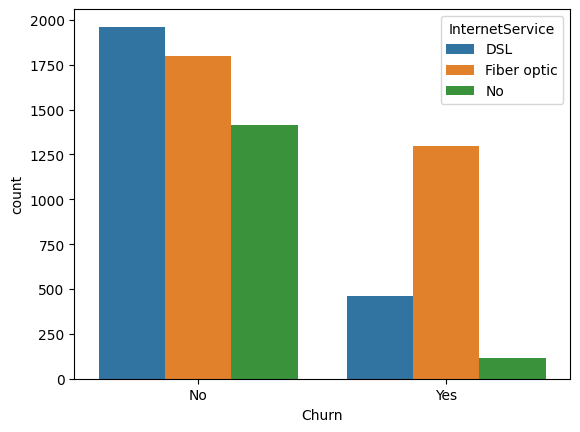

In [ ]:
sns.countplot(hue='InternetService',x='Churn',data=df)

<Axes: xlabel='Contract', ylabel='count'>

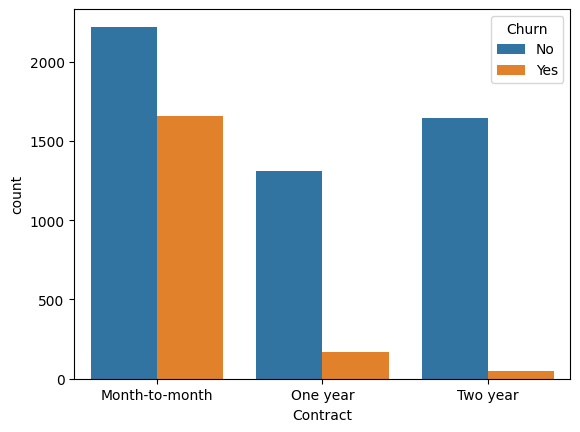

In [ ]:
sns.countplot(x='Contract',data=df,hue='Churn')

<Axes: xlabel='Churn', ylabel='tenure'>

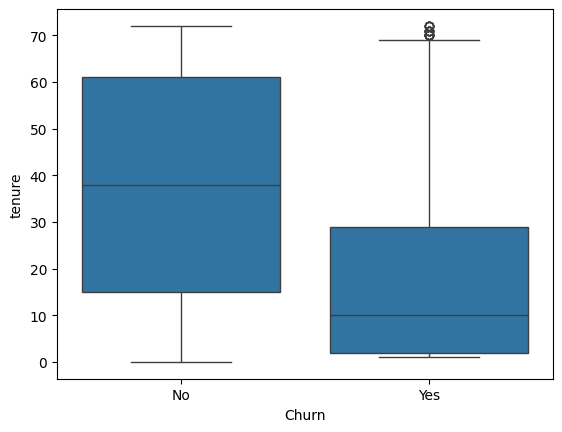

In [ ]:
sns.boxplot(x='Churn',y='tenure',data=df)

In [ ]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [ ]:
X = df.drop('Churn',axis=1)
y = df['Churn'].map({'Yes': 1, 'No': 0})

In [ ]:
df.select_dtypes(include='object').columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges',
       'Churn'],
      dtype='object')

# **Feature Engineering and Splitting the data**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

cat_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService','MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup','DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies','PaperlessBilling', 'PaymentMethod', 'TotalCharges']
num_cols = ['tenure','MonthlyCharges']
ord_col = ['Contract']

nominal_pipeline = Pipeline(steps=[
    ('encode' , OneHotEncoder(drop='first',handle_unknown='ignore'))
])

num_pipeline = Pipeline(steps=[
    ('scale' , StandardScaler())
])

ord_pipeline = Pipeline(steps=[
    ('ordinal',OrdinalEncoder(categories=[['Month-to-month', 'One year', 'Two year']]))
])

preprocessor = ColumnTransformer(transformers=[
    ('ordinal',ord_pipeline,ord_col),
    ('scaler',num_pipeline,num_cols),
    ('nominal',nominal_pipeline,cat_cols)
])

# **Model Building and Evaluation**

Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, recall_score

logistic_pipeline = Pipeline(steps=[
    ('pre-processing',preprocessor),
    ('logistic',LogisticRegression(C= 1, class_weight= 'balanced', l1_ratio= 0.5, penalty='l1',solver='saga'))
])

logistic_pipeline.fit(X_train,y_train)
y_pred_logistic = logistic_pipeline.predict(X_test)

y_pred_train = logistic_pipeline.predict(X_train)

print('Testing data evaluation')
print(classification_report(y_test, y_pred_logistic))
print(f'recall : {recall_score(y_test, y_pred_logistic)}')
print(confusion_matrix(y_test, y_pred_logistic))
print(' ')
print('Training data evaluation')
print(classification_report(y_train, y_pred_train))
print(f'recall : {recall_score(y_train, y_pred_train)}')
print(confusion_matrix(y_train, y_pred_train))

Testing data evaluation
              precision    recall  f1-score   support

           0       0.91      0.75      0.82      1539
           1       0.55      0.81      0.65       574

    accuracy                           0.77      2113
   macro avg       0.73      0.78      0.74      2113
weighted avg       0.81      0.77      0.78      2113

recall : 0.8118466898954704
[[1153  386]
 [ 108  466]]
 
Training data evaluation
              precision    recall  f1-score   support

           0       0.91      0.75      0.82      3635
           1       0.53      0.79      0.64      1295

    accuracy                           0.76      4930
   macro avg       0.72      0.77      0.73      4930
weighted avg       0.81      0.76      0.77      4930

recall : 0.7938223938223938
[[2721  914]
 [ 267 1028]]


In [ ]:
from sklearn.model_selection import GridSearchCV
lr_param_grid = {
    'logistic__penalty': ['l1', 'l2', 'elasticnet'],
    'logistic__C': [1, 2, 3, 4, 5],
    'logistic__solver': ['saga'],
    'logistic__l1_ratio': [0.5],
    'logistic__class_weight': ['balanced']
}

lr_search = GridSearchCV(logistic_pipeline, lr_param_grid, scoring='recall', n_jobs=-1, cv=5)
lr_search.fit(X_train, y_train)
print(lr_search.best_params_)

In [ ]:
from sklearn.metrics import f1_score
import numpy as np

y_proba = lr_search.best_estimator_.predict_proba(X_test)[:, 1]

thresholds_to_test = np.arange(0.1, 0.9, 0.01)
f1_scores = [f1_score(y_test, (y_proba >= t).astype(int)) for t in thresholds_to_test]

best_threshold = thresholds_to_test[np.argmax(f1_scores)]
best_f1 = max(f1_scores)

print(f"Best threshold: {best_threshold:.2f}")
print(f"Best F1: {best_f1:.3f}")
print(f"Default (0.5) F1: {f1_score(y_test, (y_proba >= 0.5).astype(int)):.3f}")

RandomForest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, recall_score

rfc_pipeline = Pipeline(steps=[
    ('pre-processing',preprocessor),
    ('rfc',RandomForestClassifier(class_weight = 'balanced', max_depth = 5, min_samples_split = 12, n_estimators = 50))
])

rfc_pipeline.fit(X_train,y_train)
y_pred_rfc = rfc_pipeline.predict(X_test)

y_pred_train_rfc = rfc_pipeline.predict(X_train)

print('Testing data evaluation')
print(classification_report(y_test, y_pred_rfc))
print(f'recall : {recall_score(y_test, y_pred_rfc)}')
print(confusion_matrix(y_test, y_pred_rfc))
print(' ')
print('Training data evaluation')
print(classification_report(y_train, y_pred_train_rfc))
print(f'recall : {recall_score(y_train, y_pred_train_rfc)}')
print(confusion_matrix(y_train, y_pred_train_rfc))

In [ ]:
rf_param_grid = {
    'rfc__n_estimators' : [100,200,50],
    'rfc__max_depth' : [2,5,10],
    'rfc__class_weight' : ['balanced'],
    'rfc__min_samples_split' : [2,5,12]
}

rfc_search = GridSearchCV(rfc_pipeline,rf_param_grid,scoring='recall',cv=5,n_jobs=-1)
rfc_search.fit(X_train,y_train)
print(rfc_search.best_params_)


{'rfc__class_weight': 'balanced', 'rfc__max_depth': 5, 'rfc__min_samples_split': 2, 'rfc__n_estimators': 50}


KNN Classifier

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn_pipeline = Pipeline(steps=[
    ('preprocessing',preprocessor),
    ('knn',KNeighborsClassifier(algorithm = 'ball_tree', n_neighbors = 5, weights = 'uniform'))
])

knn_pipeline.fit(X_train,y_train)
y_pred_knn = knn_pipeline.predict(X_test)
y_train_knn = knn_pipeline.predict(X_train)

print('Testing data evaluation')
print(classification_report(y_test, y_pred_knn))
print(f'recall : {recall_score(y_test, y_pred_knn)}')
print(confusion_matrix(y_test, y_pred_knn))
print(' ')
print('Training data evaluation')
print(classification_report(y_train, y_train_knn))
print(f'recall : {recall_score(y_train, y_train_knn)}')
print(confusion_matrix(y_train, y_train_knn))

Testing data evaluation
              precision    recall  f1-score   support

           0       0.83      0.86      0.85      1539
           1       0.59      0.54      0.56       574

    accuracy                           0.77      2113
   macro avg       0.71      0.70      0.70      2113
weighted avg       0.77      0.77      0.77      2113

recall : 0.5400696864111498
[[1320  219]
 [ 264  310]]
 
Training data evaluation
              precision    recall  f1-score   support

           0       0.88      0.91      0.89      3635
           1       0.71      0.64      0.67      1295

    accuracy                           0.84      4930
   macro avg       0.79      0.77      0.78      4930
weighted avg       0.83      0.84      0.83      4930

recall : 0.6378378378378379
[[3293  342]
 [ 469  826]]


In [ ]:
from sklearn.model_selection import GridSearchCV
knn_param_grid = {
    'knn__n_neighbors' : [3,5,10],
    'knn__weights' : ['uniform','distance'],
    'knn__algorithm' : ['ball_tree']
}

knn_search = GridSearchCV(knn_pipeline,knn_param_grid,n_jobs=-1,scoring='recall',cv=5)
knn_search.fit(X_train,y_train)
print(knn_search.best_params_)

{'knn__algorithm': 'ball_tree', 'knn__n_neighbors': 5, 'knn__weights': 'uniform'}


XgBoost

In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBClassifier
xg_pipeline = Pipeline(steps=[
    ('preprocessing',preprocessor),
    ('xgb',XGBClassifier(colsample_bytree =  0.9, learning_rate = 0.05, xgb__max_depth = 5, n_estimators = 200, xgb__subsample = 0.7))
])

xg_pipeline.fit(X_train,y_train)
y_pred_xg = xg_pipeline.predict(X_test)
y_train_xg = xg_pipeline.predict(X_train)

print('Testing data evaluation')
print(classification_report(y_test, y_pred_xg))
print(f'recall : {recall_score(y_test, y_pred_xg)}')
print(confusion_matrix(y_test, y_pred_xg))
print(' ')
print('Training data evaluation')
print(classification_report(y_train, y_train_xg))
print(f'recall : {recall_score(y_train, y_train_xg)}')
print(confusion_matrix(y_train, y_train_xg))

In [ ]:
xgb_param_grid = {
    'xgb__n_estimators': [100, 200, 300],
    'xgb__max_depth': [3, 4, 5],
    'xgb__learning_rate': [0.01, 0.05, 0.1],
    'xgb__subsample': [0.7, 0.9],
    'xgb__colsample_bytree': [0.7, 0.9],
}

xgb_search = GridSearchCV(xg_pipeline, xgb_param_grid, scoring='recall', cv=5, n_jobs=-1, verbose=1)
xgb_search.fit(X_train, y_train)
print(xgb_search.best_params_)

**ROC-AUC for Logistic Regression model** - for now it's performing best

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve, average_precision_score, precision_recall_curve
import matplotlib.pyplot as plt

y_proba = lr_search.best_estimator_.predict_proba(X_test)[:, 1]


roc_auc = roc_auc_score(y_test, y_proba)
fpr, tpr, _ = roc_curve(y_test, y_proba)


pr_auc = average_precision_score(y_test, y_proba)
precision, recall, _ = precision_recall_curve(y_test, y_proba)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(fpr, tpr, label=f'ROC-AUC = {roc_auc:.3f}')
axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend()

axes[1].plot(recall, precision, label=f'PR-AUC = {pr_auc:.3f}')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"ROC-AUC: {roc_auc:.3f}")
print(f"PR-AUC: {pr_auc:.3f}")

In [ ]:
import joblib
joblib.dump(logistic_pipeline,'Telco_customer_churn.pkl')

['Telco_customer_churn.pkl']